In [1]:
import seaborn as sns
from pathlib import Path
import time
import sys
import matplotlib.pyplot as plt
import pandas as pd

# Métriques Sklearn
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# --- Importation de nos modules ---
PROJECT_FCT = Path("../maladiescardiaques").resolve()
PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_FCT))

print(f"Racine du projet ajoutée au PATH: {PROJECT_FCT}")

try:
    # Importer les fonctions depuis vos fichiers .py
    from traitementDonnées import load_and_split_data, create_preprocessing_pipeline
    from training import get_models_config 
    
    print("Modules 'traitementDonnées' et 'training' importés avec succès.")
    
except ImportError as e:
    print(f"ERREUR D'IMPORTATION : {e}")
    print("Veuillez vérifier les noms de vos fichiers dans le dossier 'maladiescardiaques/'.")

Racine du projet ajoutée au PATH: C:\Users\sebdr\OneDrive\Bureau\sherbrooke\IFT 603 - Techniques d'apprentissages\ProjetSession\maladiescardiaques\maladiescardiaques
Modules 'traitementDonnées' et 'training' importés avec succès.


In [2]:
# Cellule 2: Chargement des données
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "cardiaque.csv"
print(f"Chargement des données depuis: {DATA_PATH}")

data = load_and_split_data(DATA_PATH)
X_train, X_test, y_train, y_test = data

print("Données chargées et divisées.")

Chargement des données depuis: C:\Users\sebdr\OneDrive\Bureau\sherbrooke\IFT 603 - Techniques d'apprentissages\ProjetSession\maladiescardiaques\data\raw\cardiaque.csv
Variable cible 'num' encodée. Valeurs uniques : [0 1]
Données chargées. Entraînement : (242, 13), Test : (61, 13)
Données chargées et divisées.


In [3]:
# Cellule 3: Entraînement des modèles (identique à model_trainer, mais on garde les résultats)

results = {}
configs = get_models_config()
preprocessor = create_preprocessing_pipeline() 

print(f"Début de l'entraînement de {len(configs)} modèles...")
print("-" * 60)

start_global = time.time()

for name, config in configs.items():
    start_model = time.time()
    print(f"🔄 Optimisation de : {name}...")
    
    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', config['model'])
    ])
    
    search = GridSearchCV(
        full_pipeline,
        config['params'],
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=0 # On met 0 pour ne pas polluer le notebook
    )
    
    search.fit(X_train, y_train)
    
    # Stocker le meilleur modèle et son score de CV
    results[name] = {
        'best_model': search.best_estimator_,
        'best_cv_score': search.best_score_ # Score F1 moyen en CV
    }
    
    end_model = time.time()
    print(f"✅ Terminé : {name} (Score CV F1: {search.best_score_:.4f}) [Durée: {end_model - start_model:.2f}s]")

end_global = time.time()
print("-" * 60)
print(f"Entraînement complet terminé en {end_global - start_global:.2f} secondes.")

Début de l'entraînement de 6 modèles...
------------------------------------------------------------
🔄 Optimisation de : LogisticRegression...
✅ Terminé : LogisticRegression (Score CV F1: 0.8224) [Durée: 10.62s]
🔄 Optimisation de : KNeighbors...
✅ Terminé : KNeighbors (Score CV F1: 0.8014) [Durée: 1.01s]
🔄 Optimisation de : DecisionTree...
✅ Terminé : DecisionTree (Score CV F1: 0.7847) [Durée: 0.72s]
🔄 Optimisation de : RandomForest...
✅ Terminé : RandomForest (Score CV F1: 0.8073) [Durée: 4.35s]
🔄 Optimisation de : SVM...
✅ Terminé : SVM (Score CV F1: 0.8171) [Durée: 0.57s]
🔄 Optimisation de : GradientBoosting...
✅ Terminé : GradientBoosting (Score CV F1: 0.7874) [Durée: 2.23s]
------------------------------------------------------------
Entraînement complet terminé en 19.51 secondes.


In [4]:
# Cellule 4: Calcul des performances finales sur le Test Set

print("Calcul des performances finales sur l'ensemble de Test...")
# Nous allons stocker les scores de TOUS les modèles sur le test set

for name, res in results.items():
    model = res['best_model']
    y_pred = model.predict(X_test)
    
    # Stocker les scores finaux
    res['final_f1_score'] = f1_score(y_test, y_pred)
    res['final_accuracy'] = accuracy_score(y_test, y_pred)
    res['predictions'] = y_pred
    
    # Pour la courbe ROC
    try:
        res['proba'] = model.predict_proba(X_test)[:, 1]
    except AttributeError:
        res['proba'] = None # Certains modèles (comme SVM sans prob=True) n'ont pas predict_proba

print("Scores finaux calculés.")

Calcul des performances finales sur l'ensemble de Test...
Scores finaux calculés.


C:\Users\sebdr\AppData\Local\Temp\ipykernel_28264\3148088887.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


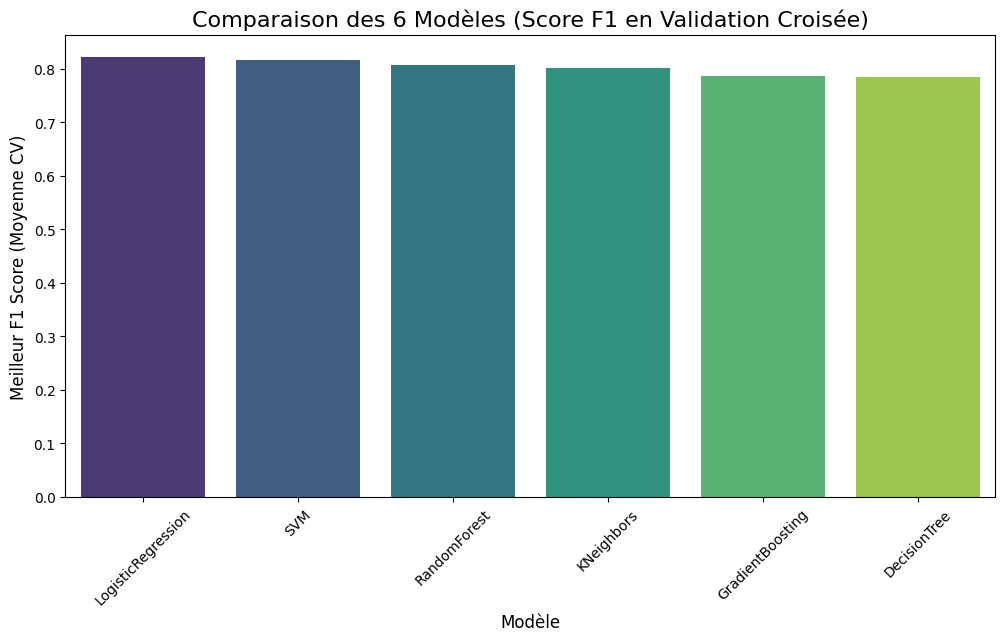

In [5]:
# Cellule 5: GRAPHIQUE 1 - Comparaison des Scores de Validation Croisée (CV)

# Extraire les scores de CV dans un DataFrame
cv_scores = {name: res['best_cv_score'] for name, res in results.items()}
df_cv_scores = pd.DataFrame.from_dict(
    cv_scores, 
    orient='index', 
    columns=['F1_Score_CV']
).sort_values(by='F1_Score_CV', ascending=False)

# Créer le graphique
plt.figure(figsize=(12, 6))
sns.barplot(
    x=df_cv_scores.index, 
    y=df_cv_scores['F1_Score_CV'], 
    palette='viridis'
)
plt.title("Comparaison des 6 Modèles (Score F1 en Validation Croisée)", fontsize=16)
plt.ylabel("Meilleur F1 Score (Moyenne CV)", fontsize=12)
plt.xlabel("Modèle", fontsize=12)
plt.xticks(rotation=45)
plt.show()

C:\Users\sebdr\AppData\Local\Temp\ipykernel_28264\326370761.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


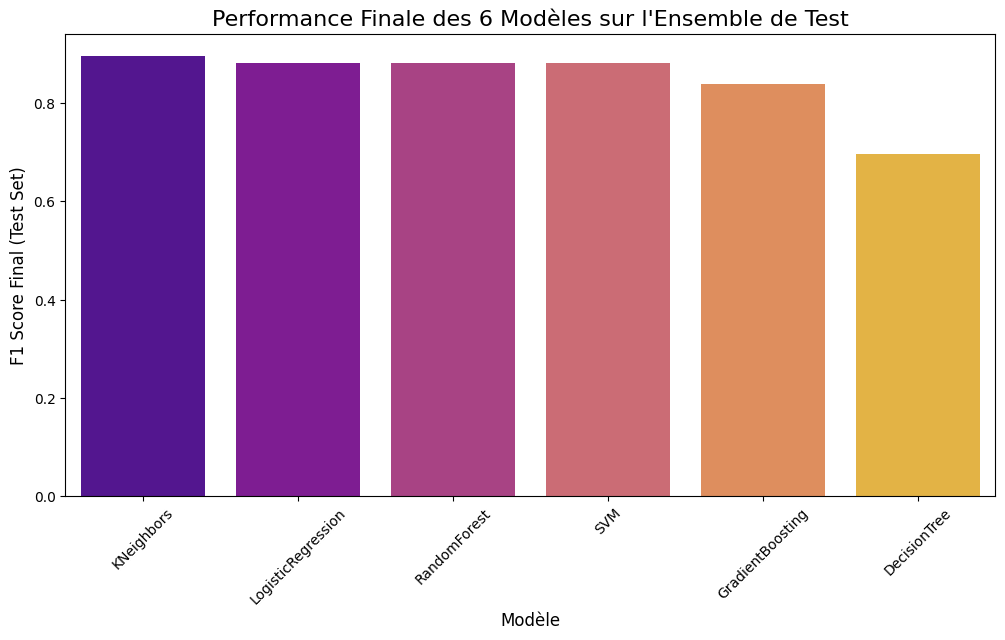

In [6]:
# Cellule 6: GRAPHIQUE 2 - Comparaison des Scores Finaux sur le Test Set

# Extraire les scores F1 finaux
final_scores = {name: res['final_f1_score'] for name, res in results.items()}
df_final_scores = pd.DataFrame.from_dict(
    final_scores, 
    orient='index', 
    columns=['F1_Score_Final_Test']
).sort_values(by='F1_Score_Final_Test', ascending=False)

# Créer le graphique
plt.figure(figsize=(12, 6))
sns.barplot(
    x=df_final_scores.index, 
    y=df_final_scores['F1_Score_Final_Test'], 
    palette='plasma'
)
plt.title("Performance Finale des 6 Modèles sur l'Ensemble de Test", fontsize=16)
plt.ylabel("F1 Score Final (Test Set)", fontsize=12)
plt.xlabel("Modèle", fontsize=12)
plt.xticks(rotation=45)
plt.show()

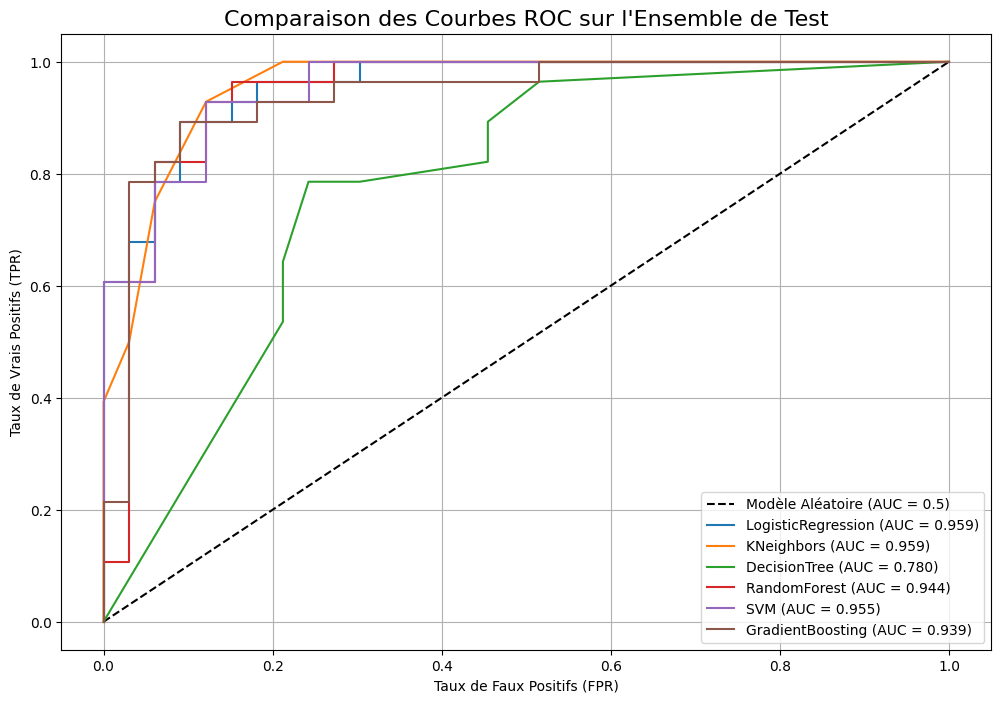

In [8]:
# Cellule 8: GRAPHIQUE 4 - Courbes ROC (Fortement recommandé pour le rapport)

plt.figure(figsize=(12, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Modèle Aléatoire (AUC = 0.5)')

# Tracer la courbe ROC pour chaque modèle
for name, res in results.items():
    if res['proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, res['proba'])
        auc = roc_auc_score(y_test, res['proba'])
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.title("Comparaison des Courbes ROC sur l'Ensemble de Test", fontsize=16)
plt.xlabel("Taux de Faux Positifs (FPR)")
plt.ylabel("Taux de Vrais Positifs (TPR)")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()